# 🚗 Uber Ride Analytics 
 
### Project Objective

## 🎯 Project Objectives

- Analyze ride demand and booking trends.
- Understand customer preferences and behavior.
- Identify factors affecting ride completion.
- Evaluate revenue, ratings, and payment patterns.
- Provide data-driven business insights.

### How This Analysis Helps the Business

- Enhances customer satisfaction through analysis of ratings and service performance.
- Supports revenue growth by understanding vehicle preferences and payment behavior.
- Enables better operational planning through demand forecasting and trend analysis.
- Helps management make data-driven decisions to improve efficiency and profitability.

## Importing essential libraries

In [1]:
import numpy as np   # Numerical computations
import pandas as pd  # Data manipulation and analysis

import matplotlib.pyplot as plt   # Data visualization
import seaborn as sns             # Statistical visualizations

# These libraries will be used throughout the project for:
# - Data cleaning and preprocessing,Exploratory Data Analysis (EDA),Creating charts and visualizations.

# 1. Import & Load Data

In [2]:
df = pd.read_csv("ncr_ride_bookings.csv")   # Loading the Dataset
df.shape    # the size and dimensionality of the dataset
df.head()  # Preview the first 5 records

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


# 2. Data Overview

In [3]:
df.info() # Dataset structure and data types
df.describe()  # Summary statistics of numerical columns
(df.isnull().mean()*100).sort_values(ascending=False) # Percentage of missing values in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

Incomplete Rides Reason              94.0
Incomplete Rides                     94.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Customer          93.0
Cancelled Rides by Driver            82.0
Driver Cancellation Reason           82.0
Driver Ratings                       38.0
Customer Rating                      38.0
Avg CTAT                             32.0
Ride Distance                        32.0
Booking Value                        32.0
Payment Method                       32.0
Avg VTAT                              7.0
Customer ID                           0.0
Booking Status                        0.0
Booking ID                            0.0
Time                                  0.0
Date                                  0.0
Pickup Location                       0.0
Drop Location                         0.0
Vehicle Type                          0.0
dtype: float64

### Key Observations

- The dataset contains 150,000 ride records and 21 attributes.
- Core booking information is complete with no missing values.
- Missing values are mainly associated with cancelled and incomplete rides.
- Booking Value, Ride Distance, Ratings, and Payment Method are available only for completed rides.
- The dataset is well-structured and suitable for further analysis.

# 3. Booking Status Distribution

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


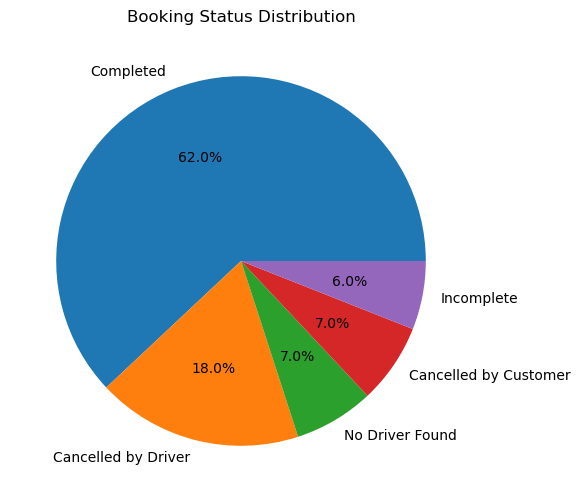

In [20]:
booking_status = df['Booking Status'].value_counts()

print(booking_status)

booking_status.plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6))

plt.ylabel('')
plt.title('Booking Status Distribution')
plt.show()

# 4. Top 10 Pickup & Drop Locations

In [7]:
pickup_drop = pd.DataFrame({
    'Top Pickup Locations': df['Pickup Location'].value_counts().head(10),
    'Top Drop Locations': df['Drop Location'].value_counts().head(10)
})

pickup_drop

,Top Pickup Locations,Top Drop Locations
AIIMS,918.0,NaN
Ashram,NaN,936.0
Badarpur,921.0,NaN
Barakhamba Road,946.0,NaN
Basai Dhankot,NaN,917.0
Cyber Hub,NaN,912.0
Dwarka Sector 21,914.0,NaN
Kalkaji,NaN,912.0
Kashmere Gate ISBT,NaN,909.0
Khandsa,949.0,NaN


### Key Observations

- Khandsa and Barakhamba Road are the most popular pickup locations.
- Ashram and Basai Dhankot receive the highest number of ride drop-offs.
- Madipur appears in both pickup and drop rankings, indicating strong two-way ride demand.
- Demand is concentrated around major commercial, transit, and residential hubs.
- These insights can help improve driver positioning and operational efficiency.

# 5. Vehicle Type Distribution Analysis

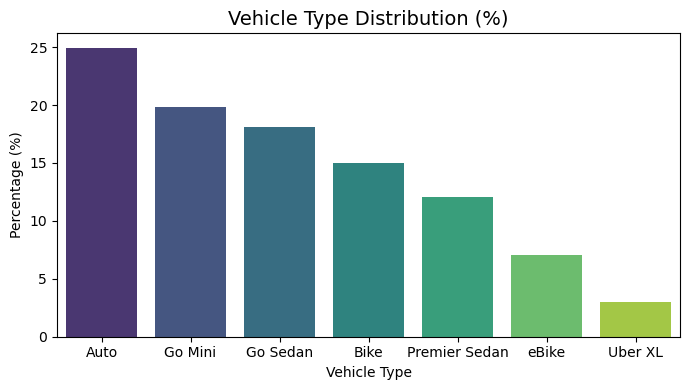

Vehicle Type
Auto             24.946000
Go Mini          19.870667
Go Sedan         18.094000
Bike             15.011333
Premier Sedan    12.074000
eBike             7.038000
Uber XL           2.966000
Name: proportion, dtype: float64

In [8]:
status_counts = df['Vehicle Type'].value_counts(normalize=True)*(100)

plt.figure(figsize=(7,4))
sns.barplot(x=status_counts.index,y=status_counts.values,hue=status_counts.index,palette='viridis',legend=False)

plt.title('Vehicle Type Distribution (%)', fontsize=14)
plt.xlabel('Vehicle Type')
plt.ylabel('Percentage (%)')
plt.tight_layout()

plt.show()

status_counts

# 6. Ratings by Vehicle Analysis

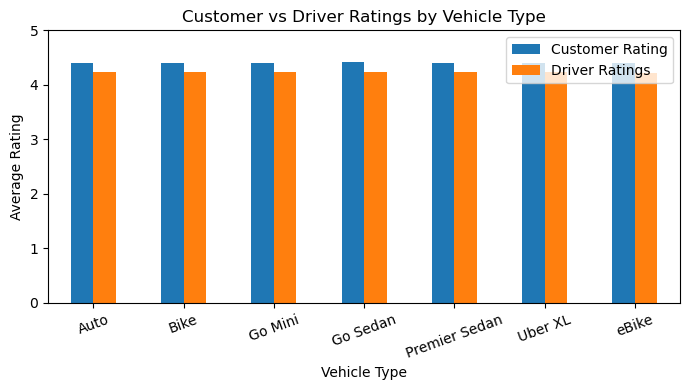

In [9]:
ratings = df.groupby('Vehicle Type')[['Customer Rating','Driver Ratings']].mean()

ratings.plot(kind='bar',figsize=(7,4),rot=20)

plt.title('Customer vs Driver Ratings by Vehicle Type')
plt.ylabel('Average Rating')
plt.ylim(0,5)
plt.tight_layout()
plt.show()

### Key Observations

- Both customer and driver ratings are consistently high across all vehicle types.
- Customer ratings are slightly higher than driver ratings in every category.
- Service quality appears uniform, with minimal variation between vehicle segments.
- The high average ratings indicate strong user satisfaction and reliable ride experiences.

# 7. Revenue Share by Payment Method Analysis

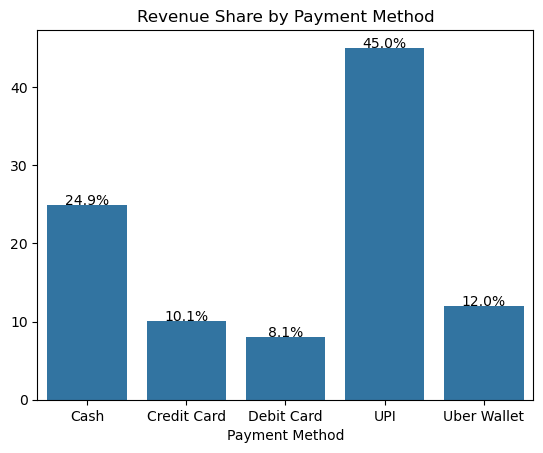

In [10]:
revenue_share = df.groupby('Payment Method')['Booking Value'].sum()
revenue_share = revenue_share / revenue_share.sum() * 100

ax = sns.barplot(x=revenue_share.index, y=revenue_share.values)

for i, v in enumerate(revenue_share):
    ax.text(i, v, f'{v:.1f}%', ha='center')

plt.title('Revenue Share by Payment Method')
plt.show()

### Key Observations

- UPI generates the highest revenue share (45%), making it the most preferred payment method.
- Cash remains an important payment mode, contributing nearly one-fourth of total revenue.
- Uber Wallet shows moderate adoption among users.
- Credit and Debit Cards contribute a relatively smaller share of revenue.
- Digital payment methods dominate the platform's revenue mix.

# 8. Cancellation Analysis

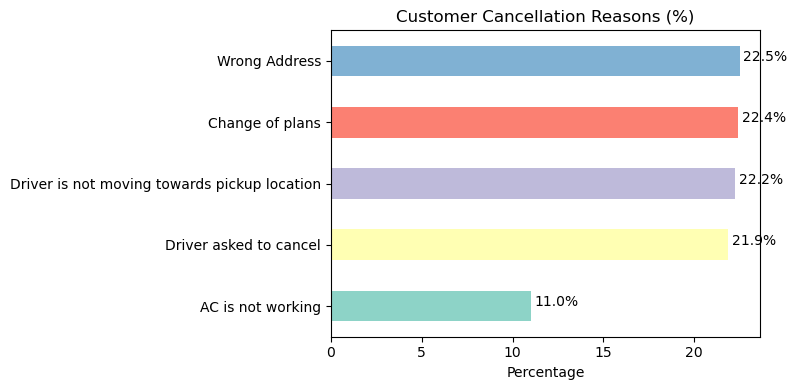

In [11]:
cust_cancel = (df['Reason for cancelling by Customer'].value_counts(normalize=True).mul(100).sort_values()
              )
colors = plt.cm.Set3(range(len(cust_cancel)))

ax = cust_cancel.plot.barh(figsize=(8,4),
    color=colors
)

for i, v in enumerate(cust_cancel):
    ax.text(v + 0.2, i, f'{v:.1f}%')

plt.title('Customer Cancellation Reasons (%)')
plt.xlabel('Percentage')
plt.ylabel('')
plt.tight_layout()
plt.show()

### key Observation

- Wrong Address and Change of Plans are the leading customer cancellation reasons.
- Driver-related issues account for a significant share of cancellations.
- AC-related complaints contribute the least to ride cancellations.
- Reducing driver delays and improving pickup efficiency could help lower cancellation rates.

# 9. Payment Method Preferences by Vehicle

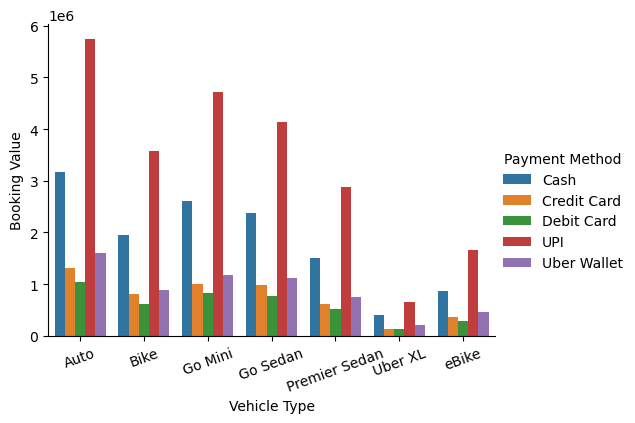

In [12]:
payment_vehicle = df.groupby(
    ['Vehicle Type','Payment Method'])['Booking Value'].sum().reset_index()

sns.catplot(data=payment_vehicle,x='Vehicle Type',y='Booking Value',hue='Payment Method',kind='bar',
    height=4,aspect=1.3)

plt.xticks(rotation=20)
plt.show()

# 10. Ratings Distribution Analysis

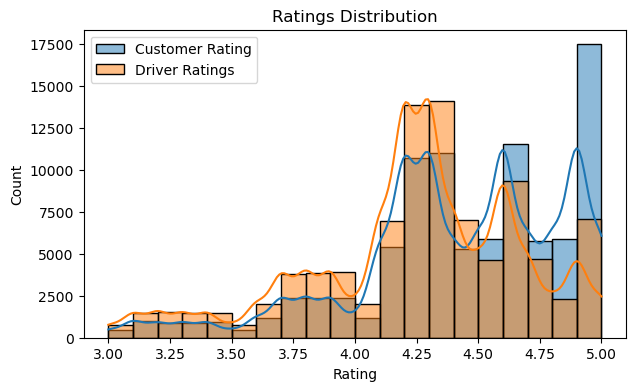

In [13]:
ratings = df[['Customer Rating', 'Driver Ratings']]

plt.figure(figsize=(7,4))

for col in ratings.columns:
    sns.histplot(ratings[col].dropna(),bins=20,kde=True,label=col)

plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.legend()
plt.show()

### key Observation

- Most customer and driver ratings fall between 4.0 and 5.0.
- Customer ratings tend to be slightly higher than driver ratings.
- The strong concentration of high ratings reflects good service quality and customer satisfaction.
- Both distributions show a consistent and healthy rating pattern across the platform.

# 11. Weekday vs Weekend Analysis

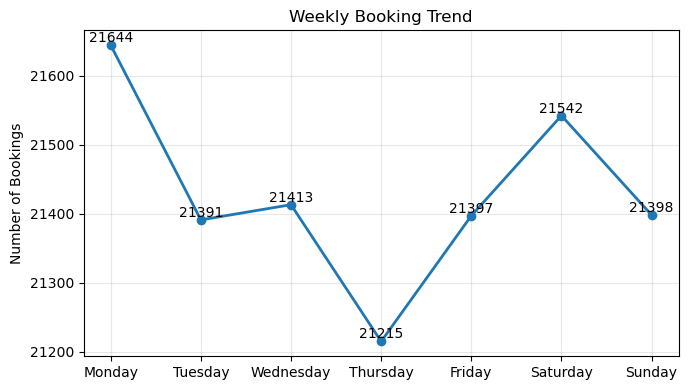

In [21]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Weekday'] = df['Date'].dt.day_name()


weekday_bookings = df.groupby('Weekday').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday', 'Sunday'])


plt.figure(figsize=(7,4))
plt.plot(weekday_bookings.index,
    weekday_bookings.values,
    marker='o',
    linewidth=2)
for x, y in zip(weekday_bookings.index, weekday_bookings.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.title('Weekly Booking Trend')
plt.ylabel('Number of Bookings')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Observations

- Booking demand remains relatively stable throughout the week, with daily bookings ranging between approximately 21,200 and 21,650 rides.
- Monday records the highest number of bookings, indicating strong demand at the beginning of the week.
- Thursday experiences the lowest booking volume, representing a temporary decline in ride demand.
- Booking activity gradually increases from Thursday to Saturday, with Saturday emerging as the second busiest day of the week.

### Business Insight

- The steady booking trend indicates predictable ride demand, which can help optimize driver allocation and operational planning.
- Slight demand peaks on Monday and Saturday may require additional driver availability to maintain service quality and reduce wait times.

# 12. Monthly Booking Trend

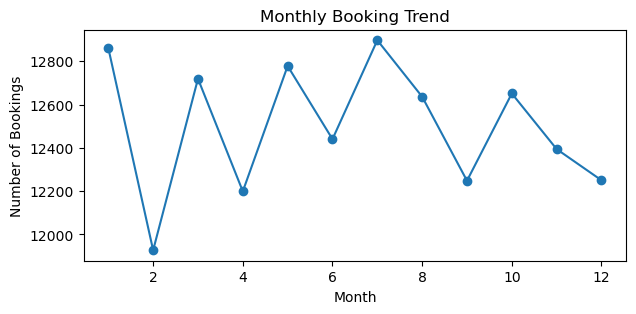

Month
1     12861
2     11927
3     12719
4     12199
5     12778
6     12440
7     12897
8     12636
9     12248
10    12651
11    12394
12    12250
Name: Booking ID, dtype: int64

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

monthly_bookings = df.groupby('Month')['Booking ID'].count()

plt.figure(figsize=(7,3))
monthly_bookings.plot(kind='line', marker='o')
plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.show()

monthly_bookings


# 13. Conclusion

- The analysis suggests that the platform operates efficiently with strong customer satisfaction, stable demand, and high digital payment adoption. -   - Future growth opportunities lie in reducing driver-related cancellations, strengthening supply in high-demand locations.
- Leveraging customer behavior insights to further enhance operational efficiency and user experience.

### Overall Observations and Business Insights

- Around 62% of bookings were successfully completed across 150,000 rides.
- Affordable vehicle categories (Auto, Go Mini, Go Sedan) dominate ride demand.
- UPI contributes the highest share of revenue, highlighting strong digital payment adoption.
- High customer and driver ratings indicate a positive ride experience.
- Driver cancellations and availability remain key areas for operational improvement.